In [1]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [5]:
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        # each iteration add more data to the training set
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.legend()

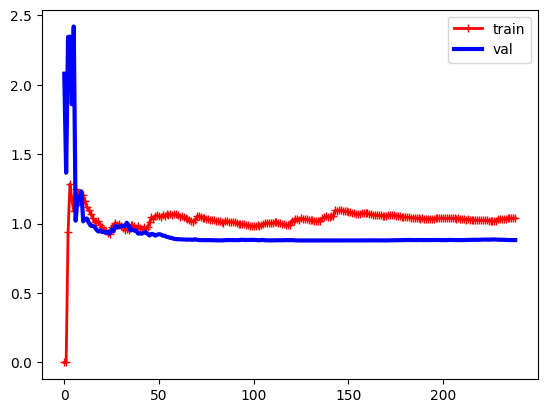

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
X = 2 * np.random.rand(300, 1)
y = 4 + 3 * X + np.random.randn(300, 1)
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

Underfitting
- if both curves have reached a plateau
- and they are close and **fairly high**.

Overfitting
- if a model performs well on the training data
- but generalizes poorly on the test data

# Polynomial Regression

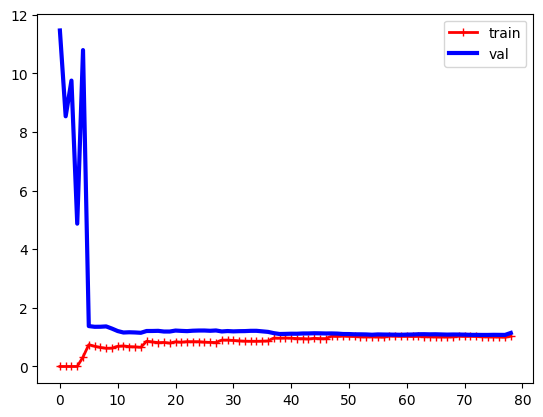

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**3 + 2 * X**2 + X + 2 + np.random.randn(m, 1)

poly_regression = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3, include_bias=False)),
    ("lin_reg", LinearRegression()),
])
plot_learning_curves(poly_regression, X, y)

#